# Hotel Booking - SVM Pipeline

Notebook nay trien khai pipeline ML cho thuat toan SVM. Su dung LinearSVC vi dataset lon va co nhieu bien one-hot.

## Phuong Phap Tuning Va Xu Ly Mat Can Bang Lop

> Cell nay duoc them de tien tham khao cho bao cao. Giai thich tai sao notebook SVM dung phuong phap tuning + xu ly imbalance KHAC voi cac notebook LR/RF/NN, va tai sao cac khac biet do hop ly.

### 1. Xu ly mat can bang lop

Su dung **`class_weight='balanced'`** trong constructor `LinearSVC(class_weight='balanced')`. Cong thuc tinh weight giong het Logistic Regression:

```
weight_class = n_samples / (n_classes * count_class)
```

Sklearn nhan weight nay vao hinge loss khi optimize. **Trung cach voi LR va RF** (cung dung `class_weight='balanced'` o constructor). Chi khac MLPClassifier do sklearn API khong ho tro `class_weight` cho MLP.

Hieu qua: baseline SVM khong co class_weight cho accuracy 0.80 nhung recall chi 0.52 (bo lo hau het booking se huy). Sau khi them class_weight, recall len 0.83 (tang ~30 pp), F1 tang ~7 pp. Trade-off: accuracy tut con 0.77 nhung **muc tieu bai toan la phat hien booking co kha nang huy**, khong phai accuracy thuan tuy.

### 2. Hyperparameter tuning

Notebook dung **GridSearchCV** voi:
- Search space: `C ∈ [0.1, 1.0, 3.0]`
- CV: 3-fold stratified
- Scoring: `f1` (phu hop voi imbalanced data hon accuracy)

**Ly do dung GridSearchCV** thay vi cac phuong phap khac:

1. **LinearSVC thuc te chi co `C` la hyperparam dang tune**:
   - `max_iter=5000` da du cho convergence.
   - `dual=False` chuan khi `n_samples > n_features` sau one-hot (tang toc training).
   - `penalty='l2'` mac dinh, khong can thay.
2. **Search space nho (3 gia tri) -> GridSearchCV full la phu hop nhat**: 3 candidates x 3 folds = **9 fits**, hoan thanh trong vai phut. Khong can RandomizedSearchCV vi khong co gi de "random" — co the thu het.
3. **Ket qua: Best C=0.1** -> regularization manh hon mac dinh (C=1.0), cho thay du lieu kha nhieu va can constraint manh.

### 3. So sanh voi cac thuat toan khac

| Thuat toan | Tuning method | Ly do |
|---|---|---|
| Logistic Regression | Encoding + L1 feature selection | Don bay khong o hyperparam |
| **SVM (LinearSVC)** (notebook nay) | **GridSearchCV(C ∈ [0.1, 1, 3])** | Search space 3 gia tri, grid du |
| Random Forest | RandomizedSearchCV(n_iter=8) | Search space 108 cau hinh, can random |
| Neural Network | Manual ParameterGrid (6 configs) | MLP train cham, can compromise |

**Ket luan**: GridSearchCV o day la lua chon don gian va day du nhat cho LinearSVC. Cach khac (manual hay random) khong co loi the gi them voi search space chi co 3 gia tri.

## Khoi Tao Thu Vien Va Duong Dan Luu Artifact

Nap thu vien can thiet, cau hinh duong dan du lieu va thu muc luu model/ket qua.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

sns.set_theme(style='whitegrid', palette='Set2')

DATA_PATH = Path('hotel_bookings.csv')
ARTIFACT_DIR = Path('model/svm')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


## Nap Du Lieu Va Kiem Tra Ban Dau

Doc dataset goc, kiem tra kich thuoc va xem nhanh cac dong dau.

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape ban dau:', df.shape)
df.head()


Shape ban dau: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Data Cleaning Va Xu Ly Gia Tri Thieu

Xu ly duplicate, missing values, bo cot thieu qua cao va loai bo cot leakage.

In [3]:
dup_count = df.duplicated().sum()
print('So duplicate truoc khi xoa:', dup_count)
df = df.drop_duplicates().reset_index(drop=True)
print('Shape sau khi xoa duplicate:', df.shape)

# Bo cot company vi thieu qua cao (~94%)
df = df.drop(columns=[c for c in ['company'] if c in df.columns])

# Xu ly missing values
df['agent'] = df['agent'].fillna('Unknown').astype(str)
df['country'] = df['country'].fillna('Unknown')
df['children'] = df['children'].fillna(df['children'].median())

# Bo cot leakage vi chi biet sau khi booking da co ket qua
leakage_cols = ['reservation_status', 'reservation_status_date']
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

print('Missing sau xu ly:')
print(df.isna().sum()[df.isna().sum() > 0])
print('Shape sau cleaning:', df.shape)


So duplicate truoc khi xoa: 31994
Shape sau khi xoa duplicate: (87396, 32)
Missing sau xu ly:
Series([], dtype: int64)
Shape sau cleaning: (87396, 29)


## EDA Nhanh Cho Target

Kiem tra phan bo nhan `is_canceled` truoc khi train.

is_canceled
0    63371
1    24025
Name: count, dtype: int64
is_canceled
0    72.51
1    27.49
Name: count, dtype: float64


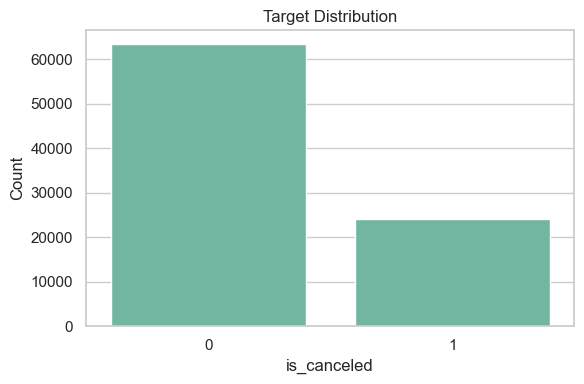

In [4]:
target_dist = df['is_canceled'].value_counts().sort_index()
print(target_dist)
print((target_dist / len(df) * 100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_canceled')
plt.title('Target Distribution')
plt.xlabel('is_canceled')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## Chia Tap Train/Test

Tach train-test theo ti le 80/20 va dung stratify de giu phan bo target.

In [5]:
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)


Train shape: (69916, 28)
Test shape : (17480, 28)


## Xay Dung Preprocessing Pipeline

Thiet lap imputation, scaling cho bien so va one-hot encoding cho bien phan loai.

In [6]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

print('Numeric cols:', len(num_cols))
print('Categorical cols:', len(cat_cols))


Numeric cols: 17
Categorical cols: 11


## Train Baseline SVM

Train LinearSVC baseline voi du lieu da preprocessing.

In [7]:
svm_baseline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearSVC(C=1.0, class_weight=None, dual=False, max_iter=5000, random_state=42))
])

svm_baseline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Danh Gia Baseline Tren Test Set

Tinh Accuracy, Precision, Recall, F1 va ROC-AUC cho SVM baseline.

In [8]:
def evaluate_svm_model(model, X_data, y_true, label):
    y_pred = model.predict(X_data)
    y_score = model.decision_function(X_data)
    return {
        'model': label,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_score)
    }

baseline_metrics = evaluate_svm_model(svm_baseline, X_test, y_test, 'svm_baseline')
baseline_eval_df = pd.DataFrame([baseline_metrics])
baseline_eval_df


,model,accuracy,precision,recall,f1,roc_auc
0,svm_baseline,0.804348,0.689674,0.524037,0.595553,0.862245


## Xu Ly Mat Can Bang Bang Class Weight

Train LinearSVC voi `class_weight='balanced'` de tang kha nang nhan dien booking bi huy.

In [9]:
svm_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearSVC(C=1.0, class_weight='balanced', dual=False, max_iter=5000, random_state=42))
])

svm_balanced.fit(X_train, y_train)
balanced_metrics = evaluate_svm_model(svm_balanced, X_test, y_test, 'svm_class_weight_balanced')
balanced_eval_df = pd.DataFrame([balanced_metrics])
balanced_eval_df


,model,accuracy,precision,recall,f1,roc_auc
0,svm_class_weight_balanced,0.768822,0.55285,0.831634,0.664174,0.863455


## Feature Engineering Va Outlier Handling

Tao cac bien moi va clipping outlier 1%-99% cho cac cot co outlier manh.

In [10]:
fe_df = df.copy()

month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

fe_df['total_nights'] = fe_df['stays_in_weekend_nights'] + fe_df['stays_in_week_nights']
fe_df['total_guests'] = fe_df['adults'] + fe_df['children'] + fe_df['babies']
fe_df['has_children'] = (fe_df['children'] > 0).astype(int)
fe_df['is_family'] = ((fe_df['children'] + fe_df['babies']) > 0).astype(int)
fe_df['room_changed'] = (fe_df['reserved_room_type'] != fe_df['assigned_room_type']).astype(int)
fe_df['has_agent'] = (fe_df['agent'] != 'Unknown').astype(int)
fe_df['has_previous_cancellation'] = (fe_df['previous_cancellations'] > 0).astype(int)
fe_df['arrival_month_number'] = fe_df['arrival_date_month'].map(month_map)

clip_bounds = {}
for col in ['adr', 'adults', 'lead_time', 'days_in_waiting_list']:
    lower = fe_df[col].quantile(0.01)
    upper = fe_df[col].quantile(0.99)
    clip_bounds[col] = {'lower': float(lower), 'upper': float(upper)}
    fe_df[col] = fe_df[col].clip(lower=lower, upper=upper)

print('Shape sau feature engineering:', fe_df.shape)
clip_bounds


Shape sau feature engineering: (87396, 37)


{'adr': {'lower': 0.0, 'upper': 261.40500000000026},
 'adults': {'lower': 1.0, 'upper': 3.0},
 'lead_time': {'lower': 0.0, 'upper': 347.0},
 'days_in_waiting_list': {'lower': 0.0, 'upper': 0.0}}

## Train SVM Sau Feature Engineering

Train LinearSVC balanced tren dataset da feature engineering va xu ly outlier.

In [11]:
X_fe = fe_df.drop(columns=['is_canceled'])
y_fe = fe_df['is_canceled']

X_fe_train, X_fe_test, y_fe_train, y_fe_test = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42, stratify=y_fe
)

num_cols_fe = X_fe_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_fe = X_fe_train.select_dtypes(include=['object']).columns.tolist()

preprocessor_fe = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols_fe),
        ('cat', categorical_transformer, cat_cols_fe)
    ]
)

svm_fe_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor_fe),
    ('model', LinearSVC(C=1.0, class_weight='balanced', dual=False, max_iter=5000, random_state=42))
])

svm_fe_balanced.fit(X_fe_train, y_fe_train)
fe_metrics = evaluate_svm_model(svm_fe_balanced, X_fe_test, y_fe_test, 'svm_fe_outlier_class_weight_balanced')
fe_eval_df = pd.DataFrame([fe_metrics])
fe_eval_df


,model,accuracy,precision,recall,f1,roc_auc
0,svm_fe_outlier_class_weight_balanced,0.773341,0.558242,0.840791,0.670985,0.870846


## Hyperparameter Tuning Cho SVM

Thu mot vai gia tri `C` bang GridSearchCV tren phien ban feature engineering.

In [12]:
svm_tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_fe),
    ('model', LinearSVC(class_weight='balanced', dual=False, max_iter=5000, random_state=42))
])

param_grid = {
    'model__C': [0.1, 1.0, 3.0]
}

grid_search = GridSearchCV(
    estimator=svm_tuning_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_fe_train, y_fe_train)

svm_tuned = grid_search.best_estimator_
tuned_metrics = evaluate_svm_model(svm_tuned, X_fe_test, y_fe_test, 'svm_fe_outlier_tuned')
tuned_eval_df = pd.DataFrame([tuned_metrics])

print('Best params:', grid_search.best_params_)
print('Best CV F1:', grid_search.best_score_)
tuned_eval_df


Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params: {'model__C': 0.1}
Best CV F1: 0.6713831038939225


,model,accuracy,precision,recall,f1,roc_auc
0,svm_fe_outlier_tuned,0.773627,0.55858,0.841415,0.671427,0.871299


## So Sanh Cac Phien Ban SVM

Tong hop ket qua baseline, class_weight, feature engineering va tuning.

In [13]:
comparison_df = pd.DataFrame([baseline_metrics, balanced_metrics, fe_metrics, tuned_metrics])
comparison_df = comparison_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
comparison_df = comparison_df.sort_values(by=['f1', 'roc_auc'], ascending=False).reset_index(drop=True)

results_path = ARTIFACT_DIR / 'svm_results.csv'
comparison_df.to_csv(results_path, index=False)

baseline_eval_df.to_csv(ARTIFACT_DIR / 'svm_baseline_evaluation.csv', index=False)
balanced_eval_df.to_csv(ARTIFACT_DIR / 'svm_class_weight_evaluation.csv', index=False)
fe_eval_df.to_csv(ARTIFACT_DIR / 'svm_fe_outlier_evaluation.csv', index=False)
tuned_eval_df.to_csv(ARTIFACT_DIR / 'svm_tuned_evaluation.csv', index=False)

print('Saved:', results_path)
comparison_df


Saved: model\svm\svm_results.csv


,model,accuracy,precision,recall,f1,roc_auc
0,svm_fe_outlier_tuned,0.773627,0.558580,0.841415,0.671427,0.871299
1,svm_fe_outlier_class_weight_balanced,0.773341,0.558242,0.840791,0.670985,0.870846
2,svm_class_weight_balanced,0.768822,0.552850,0.831634,0.664174,0.863455
3,svm_baseline,0.804348,0.689674,0.524037,0.595553,0.862245


## Final Evaluation Cho Model Tot Nhat

Chon model co F1 cao nhat, ve confusion matrix va ROC curve tren test set tuong ung.

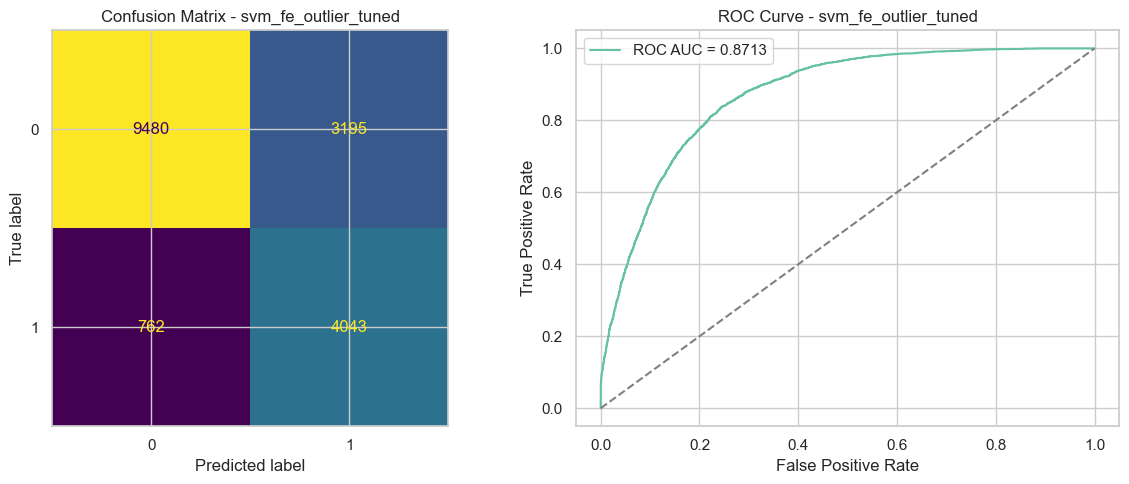

In [14]:
best_name = comparison_df.loc[0, 'model']
model_lookup = {
    'svm_baseline': (svm_baseline, X_test, y_test),
    'svm_class_weight_balanced': (svm_balanced, X_test, y_test),
    'svm_fe_outlier_class_weight_balanced': (svm_fe_balanced, X_fe_test, y_fe_test),
    'svm_fe_outlier_tuned': (svm_tuned, X_fe_test, y_fe_test)
}

best_model, X_final_test, y_final_test = model_lookup[best_name]

y_pred = best_model.predict(X_final_test)
y_score = best_model.decision_function(X_final_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_final_test, y_pred)).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix - {best_name}')

fpr, tpr, _ = roc_curve(y_final_test, y_score)
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc_score(y_final_test, y_score):.4f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve - {best_name}')
axes[1].legend()

plt.tight_layout()
plt.show()


## Kiem Tra Overfitting Cho SVM

So sanh train/test metrics cua model tot nhat de kiem tra dau hieu overfitting.

In [15]:
def evaluate_train_test_gap_svm(model, X_train_data, y_train_data, X_test_data, y_test_data, label):
    train_metrics = evaluate_svm_model(model, X_train_data, y_train_data, f'{label}_train')
    test_metrics = evaluate_svm_model(model, X_test_data, y_test_data, f'{label}_test')
    train_metrics['dataset'] = 'train'
    test_metrics['dataset'] = 'test'
    train_metrics['model_group'] = label
    test_metrics['model_group'] = label
    return train_metrics, test_metrics

if best_name in ['svm_baseline', 'svm_class_weight_balanced']:
    overfit_rows = evaluate_train_test_gap_svm(best_model, X_train, y_train, X_test, y_test, best_name)
else:
    overfit_rows = evaluate_train_test_gap_svm(best_model, X_fe_train, y_fe_train, X_fe_test, y_fe_test, best_name)

overfit_df = pd.DataFrame(overfit_rows)
overfit_df = overfit_df[['model_group', 'dataset', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]

gap_df = overfit_df.pivot(index='model_group', columns='dataset', values=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
gap_summary = pd.DataFrame(index=gap_df.index)
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    gap_summary[f'{metric}_gap_train_minus_test'] = gap_df[(metric, 'train')] - gap_df[(metric, 'test')]

overfit_df.to_csv(ARTIFACT_DIR / 'svm_overfitting_check.csv', index=False)
gap_summary.reset_index().to_csv(ARTIFACT_DIR / 'svm_overfitting_gap.csv', index=False)

display(overfit_df.round(4))
display(gap_summary.round(4))


,model_group,dataset,accuracy,precision,recall,f1,roc_auc
0,svm_fe_outlier_tuned,train,0.7769,0.5628,0.8441,0.6754,0.8739
1,svm_fe_outlier_tuned,test,0.7736,0.5586,0.8414,0.6714,0.8713


,accuracy_gap_train_minus_test,precision_gap_train_minus_test,recall_gap_train_minus_test,f1_gap_train_minus_test,roc_auc_gap_train_minus_test
model_group,,,,,
svm_fe_outlier_tuned,0.0033,0.0043,0.0027,0.0039,0.0026


## Luu Final Model SVM

Luu model SVM tot nhat voi ten `final_model` va metadata di kem.

In [16]:
final_model = best_model
final_model_name = best_name

final_model_path = ARTIFACT_DIR / 'final_model.joblib'
final_metadata_path = ARTIFACT_DIR / 'final_model_metadata.json'

joblib.dump(final_model, final_model_path)

final_metadata = {
    'final_model_name': final_model_name,
    'algorithm': 'LinearSVC',
    'selection_metric': 'f1_then_roc_auc',
    'best_params': grid_search.best_params_,
    'test_metrics': comparison_df.loc[comparison_df['model'] == final_model_name].iloc[0].to_dict(),
    'note': 'LinearSVC is used instead of kernel SVC because the dataset is large after one-hot encoding.'
}

final_metadata_path.write_text(json.dumps(final_metadata, ensure_ascii=False, indent=2), encoding='utf-8')

print('Saved final model:', final_model_path)
print('Saved final metadata:', final_metadata_path)


Saved final model: model\svm\final_model.joblib
Saved final metadata: model\svm\final_model_metadata.json


## Ket Luan Buoc SVM

Tong ket ket qua SVM va dung bang so sanh de doi chieu voi cac thuat toan khac sau nay.

In [17]:
print('Best SVM model:', final_model_name)
display(comparison_df)


Best SVM model: svm_fe_outlier_tuned


,model,accuracy,precision,recall,f1,roc_auc
0,svm_fe_outlier_tuned,0.773627,0.558580,0.841415,0.671427,0.871299
1,svm_fe_outlier_class_weight_balanced,0.773341,0.558242,0.840791,0.670985,0.870846
2,svm_class_weight_balanced,0.768822,0.552850,0.831634,0.664174,0.863455
3,svm_baseline,0.804348,0.689674,0.524037,0.595553,0.862245


## Nhan Xet Va Ket Luan SVM

### Ket qua cuoi cung
- **Best variant**: `svm_fe_outlier_tuned` (LinearSVC, C = 0.1)
- **Test metrics**: Accuracy = 0.7736 | Precision = 0.5586 | Recall = 0.8414 | F1 = 0.6714 | ROC-AUC = 0.8713
- **Overfitting gap (F1 train - test)**: ~0.004 -> khong overfit.

### Nhan xet chinh
1. **Ket qua gan nhu trung khop voi Logistic Regression** (F1 0.67 vs 0.67, ROC-AUC 0.87 vs 0.87). Dieu nay hoan toan hop ly vi LinearSVC va LogisticRegression cung la **mo hinh tuyen tinh trong khong gian one-hot**; chi khac nhau o loss function (hinge vs log-loss). Ca hai deu cham mot tran bien tuyen tinh tren cung tap feature.
2. **C = 0.1 (regularization manh hon mac dinh C = 1.0) duoc chon** -> du lieu kha nhieu, can regularization manh de tranh fit noise.
3. **Class_weight = 'balanced' van la dong gop chinh** giong nhu LR: baseline accuracy 0.80 nhung recall chi 0.52, sau class_weight recall len 0.83.
4. **Khong co predict_proba** vi LinearSVC chi cung cap `decision_function`. ROC-AUC duoc tinh tu decision score (rank-based), van hop le; nhung **frontend khong hien thi duoc xac suat %** cho SVM neu khong boc CalibratedClassifierCV.

### Diem yeu
- Performance ngang LR -> khong them gia tri nhieu so voi baseline.
- Thieu predict_proba -> kho integrate vao UI co hien xac suat.
- Training cham hon LR voi cung 1 thuat toan tuyen tinh.

### Vai tro trong bao cao
SVM dong vai tro **kiem chung**: chung minh rang ket qua LR khong phai do mot thuat toan cu the, ma la **gioi han cua moi mo hinh tuyen tinh tren bai toan nay**. Neu muon vuot F1 = 0.67, phai chuyen sang mo hinh phi tuyen (RF, NN). Khong nen chon SVM lam model deploy.